<a href="https://colab.research.google.com/github/langsa598-prog/DDPM-Experiment/blob/main/DDPM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
from PIL import Image
from torchvision import transforms

# 이미지 마운트 경로
img_path = "/content/drive/MyDrive/COBI.jpg"

# 이미지 열기
image = Image.open(img_path).convert('RGB')

# 전처리 (이전 단계에서 이야기한 -1 ~ 1 범위 정규화 포함)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

x_0 = transform(image).unsqueeze(0) # [1, 3, 128, 128] 형태의 텐서
print(f"이미지 텐서 모양: {x_0.shape}")
print(f"최솟값: {x_0.min()}, 최댓값: {x_0.max()}")

이미지 텐서 모양: torch.Size([1, 3, 128, 128])
최솟값: -1.0, 최댓값: 0.9921568632125854


# 1. 실험 결과 분석
이전 코드에서 이미지를 -1에서 1 사이로 정규화하는 과정 거침

Case A (With scaling): 50번이나 노이즈를 더했음에도 불구하고 값이 -3.84 ~ 3.72 정도로 어느 정도 제어된 상태, 즉 시각화된 이미지를 봐도 노이즈가 고르게 분포.

Case B (Without scaling): 값이 -6.89 ~ 6.44까지 치솟음. $\sqrt{1-\beta}$ 로 기존 값을 깎아주지 않으니, 노이즈가 더해질수록 전체적인 에너지가 계속 커져서 픽셀 값이 범위를 크게 벗어난 경향을 보임.



# 2. 과제 핵심 정답
1. **분산 제어 (Variance Preservation)**

 - 매 단계마다 원본 데이터의 크기를 살짝 줄임으로써, 새로 추가되는 노이즈의 분산과 합쳐졌을 때 **전체 분산이 1로 유지**되도록 설계

2. **학습의 안정성**

- 만약 Case B처럼 값이 계속 커지면, 딥러닝 모델이 이 날뛰는 숫자들을 감당하지 못해 학습이 제대로 되지 않음

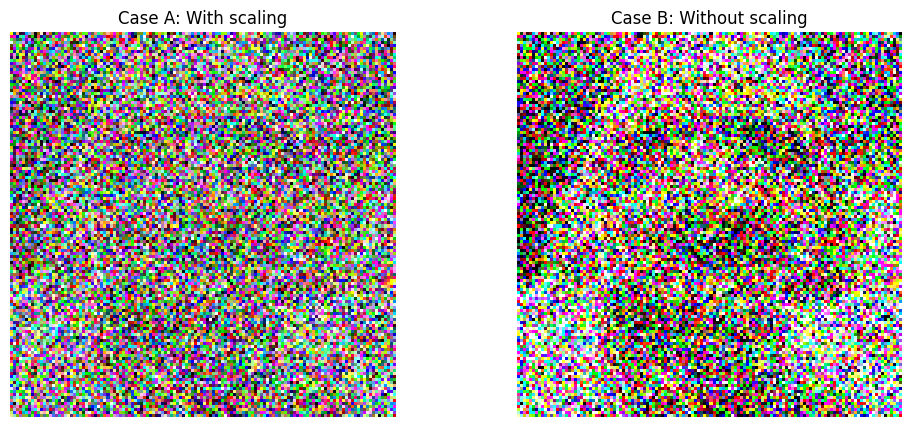

Case A (공식 적용) - 최소: -3.84, 최대: 3.72
Case B (미적용) - 최소: -6.89, 최대: 6.44


In [3]:
import torch
import matplotlib.pyplot as plt

# 설정값
steps = 50
beta = 0.05
sqrt_one_minus_beta = (1 - beta)**0.5
sqrt_beta = beta**0.5

# 실험을 위한 복사본 생성
x_a = x_0.clone() # Case A용
x_b = x_0.clone() # Case B용

# 50번 반복 루프
for i in range(steps):
    noise = torch.randn_like(x_0)

    # Case A: 공식대로 스케일링 적용
    x_a = sqrt_one_minus_beta * x_a + sqrt_beta * noise

    # Case B: 스케일링 없이 노이즈만 추가
    x_b = x_b + sqrt_beta * noise

# 결과 시각화를 위한 함수
def show(tensor, title):
    # [-1, 1] -> [0, 1]로 변환하여 시각화
    img = tensor.squeeze().permute(1, 2, 0).detach().cpu()
    img = (img + 1) / 2
    img = torch.clamp(img, 0, 1) # 범위를 벗어나는 값 제어
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); show(x_a, "Case A: With scaling")
plt.subplot(1, 2, 2); show(x_b, "Case B: Without scaling")
plt.show()

# 실제 값의 범위 확인
print(f"Case A (공식 적용) - 최소: {x_a.min():.2f}, 최대: {x_a.max():.2f}")
print(f"Case B (미적용) - 최소: {x_b.min():.2f}, 최대: {x_b.max():.2f}")